<a href="https://colab.research.google.com/github/CharlieHubbard7/NFLResearch/blob/main/(6_2_26)_NFL_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Research

This notebook contains my work for the third week of work with Professor Ron Yurko at Carnegie Mellon's Sports Analytics Center. I use Madden ratings to explore what stats teams value in players of different position groups

##Data Wrangling

### Installs and Imports


In [1]:
!pip install nflreadpy #This is from the NFLverse package: https://github.com/nflverse/nflreadpy
!pip install rapidfuzz -q #This helps match the NFL roster with the madden data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import string
import re
import math
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import nflreadpy as nfl
from rapidfuzz import fuzz, process
pd.set_option('display.max_columns', 250)
pd.set_option('display.min_rows', 10)

### NFL Verse Stats

In [3]:
pbp = nfl.load_pbp().to_pandas() # play-by-play data
player_stats = nfl.load_player_stats().to_pandas() # player game or season statistics
team_stats = nfl.load_team_stats().to_pandas() # team game or season statistics
# schedules = nfl.load_schedules().to_pandas() # game schedules and results
players = nfl.load_players().to_pandas() # player information
rosters = nfl.load_rosters().to_pandas() # team rosters
rosters_weekly = nfl.load_rosters_weekly().to_pandas() # team rosters by season-week
snap_counts = nfl.load_snap_counts().to_pandas() # snap counts
nextgen_stats = nfl.load_nextgen_stats().to_pandas() # advanced stats from nextgenstats.nfl.com
ftn_charting = nfl.load_ftn_charting().to_pandas() # charted stats from ftnfantasy.com/data
participation = nfl.load_participation().to_pandas() # participation data (historical)
draft_picks = nfl.load_draft_picks().to_pandas() # nfl draft picks
injuries = nfl.load_injuries().to_pandas() # injury statuses and practice participation
contracts = nfl.load_contracts().to_pandas() # historical contract data from OTC
officials = nfl.load_officials().to_pandas() # officials for each game
combine = nfl.load_combine().to_pandas() # nfl combine results
depth_charts = nfl.load_depth_charts().to_pandas() # depth charts
trades = nfl.load_trades().to_pandas() # trades
ff_playerids = nfl.load_ff_playerids().to_pandas() # ffverse/dynastyprocess player ids
ff_rankings = nfl.load_ff_rankings().to_pandas() # fantasypros rankings
ff_opportunity = nfl.load_ff_opportunity().to_pandas() # expected yards, touchdowns, and fantasy points

### Historical Madden Data

Credit to: https://github.com/theedgepredictor/nfl-madden-data/tree/main/data/madden/dataset for the data collection

In [4]:
madden_long = pd.read_parquet("/content/drive/MyDrive/ipynb stuff/madden_hist.parquet")
madden_long.head()

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year
0,00-0004543,SHANEDRONETT_d_line,DronSh20,Shane Dronett,def,d_line,DL,2001,ATL,1.0,75.0,53.0,65.0,58.0,79.0,84.0,84.0,79.0,81.0,43.0,7.347195,4,11,35.306958,66.518996,11.0,20.0,20.0,20.0,16.696763,19.318944,28.0,-2.261149,-1.546120,2.340851,3.478826,22.0,6.519022,10.549796,11.996476,9.005981,8.412261,8.034401,16.0,16.0,0.483380,15.249485,17.082539,81.0,51.752871,8.673651,66.456748,21.0,24.0,0.675884,2001
1,00-0012842,JASONPETER_d_line,PeteJa20,Jason Peter,def,d_line,DL,2001,CAR,1.0,74.0,66.0,74.0,64.0,84.0,78.0,84.0,80.0,67.0,51.0,7.889415,5,7,47.836493,58.864012,10.0,21.0,21.0,21.0,18.295792,21.480056,24.0,0.980120,-0.375920,8.238861,7.495244,21.0,5.982346,9.869347,12.073328,5.724684,4.637821,9.797546,27.0,18.0,9.782409,19.028072,23.221269,72.0,54.472249,12.652961,69.286862,18.0,19.0,3.772098,2001
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.0,72.0,62.0,75.0,65.0,70.0,70.0,82.0,64.0,52.0,25.090824,8,9,51.656422,55.302556,32.0,14.0,14.0,14.0,11.934877,13.800475,24.0,19.994085,18.021897,24.959818,21.045019,40.0,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.0,24.0,-5.096101,32.979157,37.209780,74.0,51.286358,28.416331,72.007990,11.0,33.0,1.131921,2001
3,00-0002142,JUNIORBRYANT_d_line,BryaJu20,Junior Bryant,def,d_line,DL,2001,SF,1.0,72.0,49.0,62.0,55.0,81.0,81.0,84.0,84.0,79.0,43.0,5.111116,5,9,36.576845,65.727568,24.0,11.0,11.0,11.0,9.494538,11.093699,14.0,-8.819708,-2.912042,-5.407254,-5.493794,14.0,7.008726,10.117281,12.240143,-1.108932,-1.319240,1.354661,29.0,27.0,7.181824,14.503342,17.728221,82.0,51.302609,6.509206,64.948565,12.0,14.0,1.162361,2001
4,00-0018054,REINARDWILSON_d_line,WilsRe20,Reinard Wilson,def,d_line,DL,2001,CIN,1.0,69.0,70.0,70.0,65.0,78.0,69.0,78.0,77.0,65.0,50.0,16.121217,7,9,50.852213,56.274011,31.0,16.0,16.0,16.0,16.041897,17.385281,26.0,12.748664,9.218156,18.243457,14.183115,26.0,7.190139,10.575620,11.980324,12.149089,9.289694,10.978948,13.0,9.0,-2.869764,26.808503,31.008670,69.0,51.400124,22.833778,69.883798,17.0,21.0,2.545349,2001


## Analysis

### Exploring Variation of Players Rankings



In [ ]:
active_contracts = contracts.query("is_active == True")
contracts_short = active_contracts[["apy_cap_pct", "gsis_id", "draft_round", "draft_overall"]]
madden_long_2025 = madden_long.query("year == 2025")
df = madden_long_2025.merge(contracts_short, left_on="player_id", right_on="gsis_id")
df = df.dropna(subset = "draft_overall")
df.head()

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,rookie_year,years_in_nfl,baseline_overall,overall_vs_baseline,apy_cap_pct,gsis_id,draft_round,draft_overall
0,00-0036220,DERRICKBROWN_19980415,BrowDe05,Derrick Brown,def,d_line,DL,2025,CAR,0.0,95.0,70.0,76.0,73.0,87.0,98.0,95.0,95.0,97.0,68.0,60.0,0,7,58.0,95.0,41.0,35.0,30.0,27.0,25.0,36.0,56.0,53.0,52.0,50.0,52.0,53.0,42.0,34.998400,33.0,49.0,47.0,39.0,50.0,48.0,93.0,24.0,30.0,94.0,84.0,23.0,85.0,14.0,22.0,30.0,2025,2020.0,6.0,78.0,17.0,0.094,00-0036220,1.0,7.0
1,00-0036981,CHRISTIANBARMORE_19990728,BarmCh00,Christian Barmore,def,d_line,DL,2025,NE,0.0,80.0,64.0,75.0,74.0,78.0,89.0,89.0,91.0,86.0,81.0,32.0,3,6,56.0,85.0,24.0,6.0,6.0,6.0,6.0,6.0,41.0,25.0,30.0,23.0,24.0,37.0,15.0,10.352678,9.0,25.0,23.0,16.0,45.0,45.0,89.0,17.0,25.0,86.0,82.0,13.0,83.0,12.0,11.0,10.0,2025,2021.0,5.0,73.0,7.0,0.082,00-0036981,2.0,38.0
2,00-0039854,DARIUSROBINSON_20010913,RobiDa01,Darius Robinson,def,d_line,DL,2025,ARI,0.0,73.0,77.0,77.0,74.0,79.0,87.0,85.0,87.0,71.0,84.0,16.0,0,6,58.0,72.0,17.0,12.0,19.0,27.0,11.0,13.0,29.0,24.0,28.0,14.0,17.0,25.0,10.0,9.958793,6.0,21.0,25.0,10.0,40.0,35.0,81.0,32.0,33.0,78.0,80.0,25.0,75.0,21.0,24.0,8.0,2025,2024.0,2.0,72.0,1.0,0.014,00-0039854,1.0,27.0
3,00-0039859,BRANDONDORLUS_20010322,DorlBr00,Brandon Dorlus,def,d_line,DL,2025,ATL,0.0,71.0,70.0,82.0,77.0,85.0,84.0,89.0,88.0,67.0,75.0,38.0,2,4,52.0,64.0,22.0,6.0,6.0,6.0,6.0,6.0,26.0,28.0,31.0,25.0,29.0,35.0,13.0,5.544343,3.0,20.0,17.0,17.0,44.0,44.0,87.0,22.0,29.0,79.0,81.0,23.0,78.0,19.0,21.0,9.0,2025,2024.0,2.0,70.0,1.0,0.005,00-0039859,4.0,109.0
4,00-0037815,CAMERONTHOMAS_20000107,ThomCa03,Cameron Thomas,def,d_line,DL,2025,CLE,0.0,70.0,82.0,84.0,78.0,78.0,77.0,85.0,92.0,65.0,81.0,34.0,2,2,73.0,64.0,22.0,6.0,6.0,6.0,6.0,6.0,41.0,41.0,39.0,36.0,39.0,39.0,34.0,29.773183,28.0,37.0,38.0,34.0,45.0,45.0,87.0,25.0,35.0,83.0,78.0,18.0,82.0,14.0,15.0,10.0,2025,2022.0,4.0,66.0,4.0,0.010,00-0037815,3.0,87.0


In [ ]:
temp = (df
        .query("rookie_year == 2020")
        .sort_values("baseline_overall", ascending=False))
temp.head()

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,rookie_year,years_in_nfl,baseline_overall,overall_vs_baseline,apy_cap_pct,gsis_id,draft_round,draft_overall
104,00-0036321,CHASEYOUNG_19990101,YounCh04,Chase Young,def,d_line,DL,2025,NO,2.000000,79.000000,84.000000,87.000000,83.000000,79.00000,86.000000,89.000000,83.000000,74.000000,84.00000,34.000000,4,10,71.000000,72.000000,32.000000,28.000000,25.000000,20.000000,15.000000,33.000000,43.000000,36.000000,39.000000,36.000000,38.000000,33.000000,14.000000,6.561640,5.000000,24.000000,25.000000,17.000000,45.00000,45.000000,88.000000,34.000000,47.000000,83.00000,82.000000,27.000000,83.000000,22.000000,14.000000,10.00000,2025,2020.0,6.0,80.0,-1.000000,0.061,00-0036321,1.0,2.0
0,00-0036220,DERRICKBROWN_19980415,BrowDe05,Derrick Brown,def,d_line,DL,2025,CAR,0.000000,95.000000,70.000000,76.000000,73.000000,87.00000,98.000000,95.000000,95.000000,97.000000,68.00000,60.000000,0,7,58.000000,95.000000,41.000000,35.000000,30.000000,27.000000,25.000000,36.000000,56.000000,53.000000,52.000000,50.000000,52.000000,53.000000,42.000000,34.998400,33.000000,49.000000,47.000000,39.000000,50.00000,48.000000,93.000000,24.000000,30.000000,94.00000,84.000000,23.000000,85.000000,14.000000,22.000000,30.00000,2025,2020.0,6.0,78.0,17.000000,0.094,00-0036220,1.0,7.0
1020,00-0036260,JAVONKINLAW_19971003,KinlJa00,Javon Kinlaw,def,d_line,DL,2025,WAS,8.000000,73.000000,72.000000,77.000000,73.000000,75.00000,86.000000,86.000000,75.000000,75.000000,76.00000,32.000000,2,6,62.000000,72.000000,24.000000,6.000000,6.000000,6.000000,6.000000,6.000000,34.000000,24.000000,31.000000,24.000000,29.000000,31.000000,15.000000,6.909281,3.000000,17.000000,16.000000,17.000000,45.00000,45.000000,85.000000,17.000000,25.000000,82.00000,80.000000,16.000000,78.000000,12.000000,19.000000,10.00000,2025,2020.0,6.0,76.0,-3.000000,0.054,00-0036260,1.0,14.0
2252,00-0036281,C.J.HENDERSON_19980930,HendCJ00,C.J. Henderson,def,d_field,DB,2025,PIT,2.451943,73.779947,85.010572,91.116283,90.609303,89.98909,69.093842,86.879343,86.573611,74.864407,88.61296,41.247069,3,3,83.042068,70.909391,27.606184,13.292478,10.984305,9.970569,10.674438,12.949658,63.099242,68.417966,41.736153,63.409009,71.389259,69.566313,33.166564,23.411137,19.489427,67.250391,57.186999,30.010909,30.83948,29.414928,57.842199,67.408401,69.682385,66.18928,75.182392,76.036338,76.438248,17.098723,19.941063,54.22242,2025,2020.0,6.0,76.0,-2.220053,0.004,00-0036281,1.0,9.0
6296,00-0036442,JOEBURROW_19961210,BurrJo01,Joe Burrow,off,quarterback,QB,2025,CIN,16.000000,97.000000,83.000000,86.000000,84.000000,97.00000,68.000000,97.000000,92.000000,99.000000,74.00000,57.000000,1,7,79.000000,27.000000,88.000000,99.000000,97.000000,96.000000,86.000000,91.000000,62.000000,86.000000,50.000000,68.000000,64.000000,40.000000,28.000000,19.751931,15.000000,26.000000,19.000000,18.000000,15.00000,15.000000,29.000000,29.000000,33.000000,36.00000,29.000000,25.000000,38.000000,17.000000,21.000000,10.00000,2025,2020.0,6.0,76.0,21.000000,0.245,00-0036442,1.0,1.0


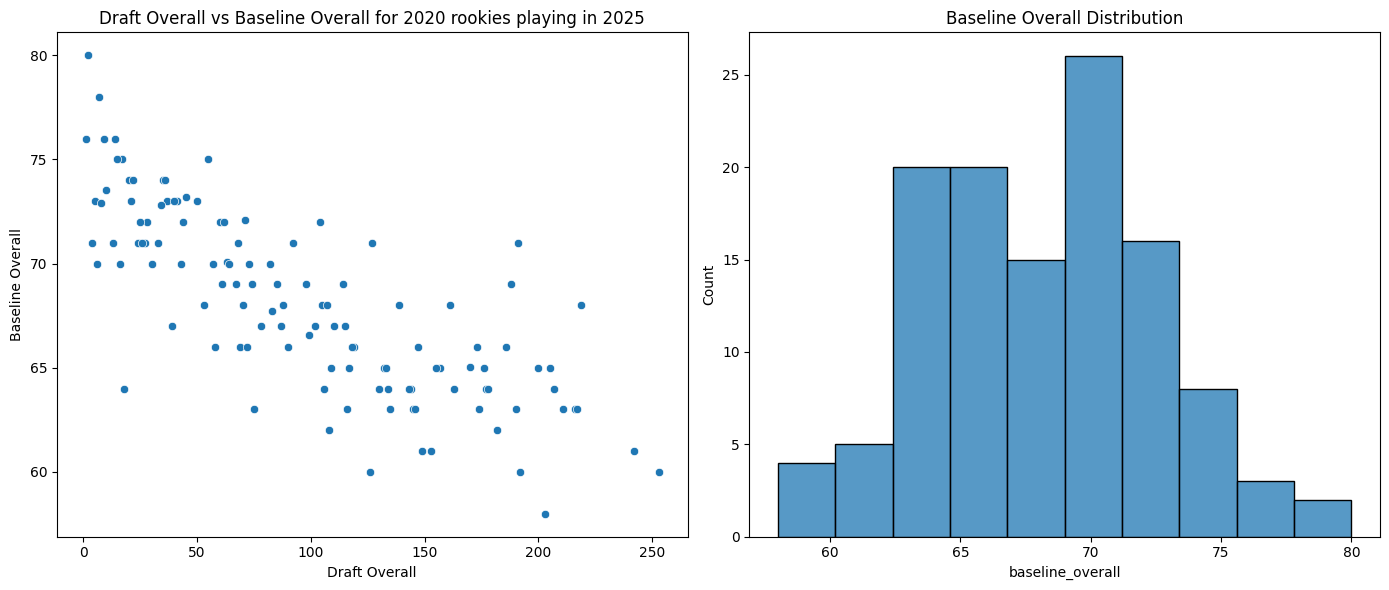

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(temp, x="draft_overall", y="baseline_overall", ax=ax1)
sns.histplot(temp, x="baseline_overall", ax=ax2)  # ← histplot, not displot

ax1.set_xlabel("Draft Overall")
ax1.set_ylabel("Baseline Overall")
ax1.set_title("Draft Overall vs Baseline Overall for 2020 rookies playing in 2025")
ax2.set_title("Baseline Overall Distribution")

plt.tight_layout()
plt.show()

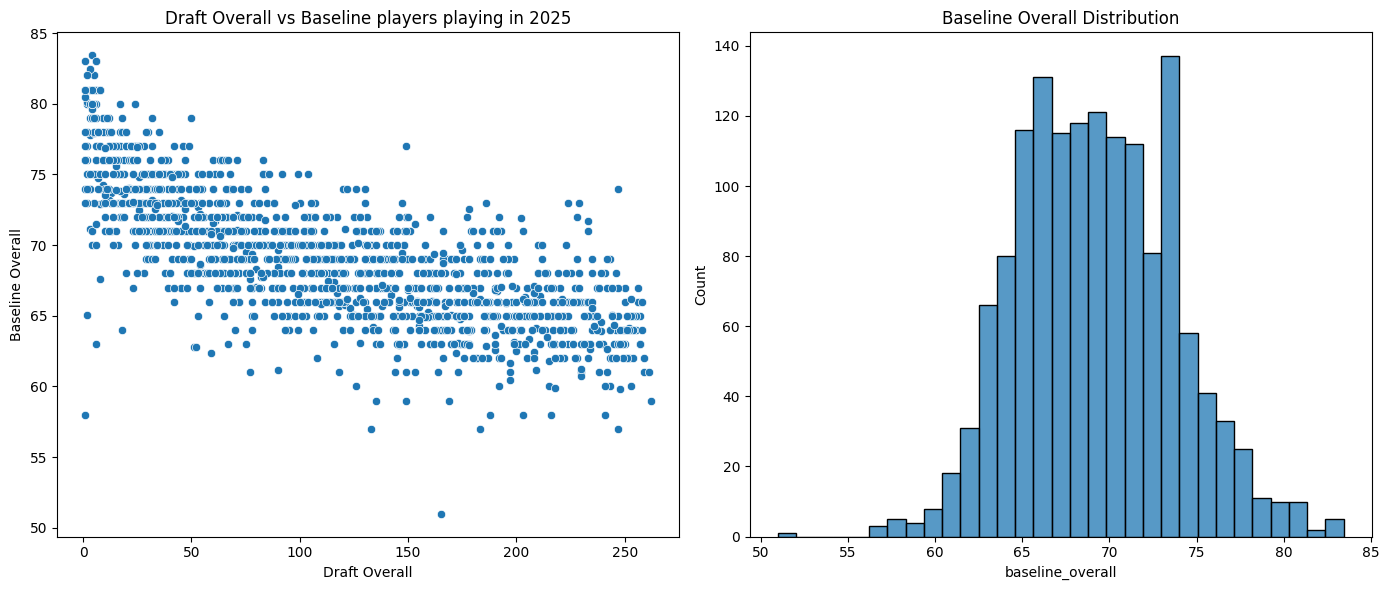

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(df, x="draft_overall", y="baseline_overall", ax=ax1)
sns.histplot(df, x="baseline_overall", ax=ax2)  # ← histplot, not displot

ax1.set_xlabel("Draft Overall")
ax1.set_ylabel("Baseline Overall")
ax1.set_title("Draft Overall vs Baseline players playing in 2025")
ax2.set_title("Baseline Overall Distribution")

plt.tight_layout()
plt.show()

### Continued Exploration


In [ ]:
df_full = madden_long.merge(players[["rookie_season", "last_season", "gsis_id", "draft_year", "draft_round", "draft_pick"]], left_on="player_id", right_on="gsis_id")
df_drafted = df_full[df_full['draft_year'].notna()]
df_working = df_drafted.query("rookie_season > 2000")
df = df_working.copy()
df["year_in_nfl"] = df["year"] - df["rookie_season"]

In [ ]:
rookie_map = df[df['year_in_nfl'] == 0].set_index('player_id')['overallrating']
df['rookie_overall'] = df['player_id'].map(rookie_map)
df["rating_relative_to_rookie"] = df["overallrating"] - df["rookie_overall"]

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,rookie_season,last_season,gsis_id,draft_year,draft_round,draft_pick,year_in_nfl,rookie_overall,rating_relative_to_rookie
116,00-0020459,JAMALREYNOLDS_d_line,ReynJa20,Jamal Reynolds,def,d_line,DL,2001,GB,4.61086,79.0,72.0,83.0,76.0,78.0,73.0,88.0,85.0,64.0,60.0,13.928256,5,11,47.738742,52.942789,15.0,21.0,21.0,21.0,17.356663,20.805043,15.0,14.519759,8.996859,23.991852,22.437692,33.0,10.151774,11.892505,12.693256,12.293937,7.395690,14.332235,11.0,12.0,3.324223,27.272776,29.680041,69.0,53.186884,22.930081,74.745695,19.0,22.0,1.439833,2001,2001,2003,00-0020459,2001.0,1.0,10.0,0,79.000000,0.000000
117,00-0020535,JUSTINSMITH_19790920,SmitJu20,Justin Smith,def,d_line,DL,2001,CIN,4.61086,79.0,67.0,82.0,76.0,85.0,77.0,80.0,73.0,66.0,58.0,7.920525,3,6,40.323669,59.834627,22.0,21.0,21.0,21.0,16.433431,20.294446,15.0,8.629725,2.961450,18.548155,11.311415,19.0,11.235782,11.530147,11.692559,6.724469,2.138416,16.285808,23.0,22.0,20.447276,25.551392,30.165120,72.0,50.433495,13.792209,76.216600,20.0,11.0,3.217043,2001,2001,2014,00-0020535,2001.0,1.0,4.0,0,79.000000,0.000000
120,00-0020426,CASEYHAMPTON_19770903,HampCa00,Casey Hampton,def,d_line,DL,2001,PIT,4.61086,77.0,63.0,66.0,59.0,89.0,90.0,82.0,87.0,69.0,48.0,9.579246,3,6,35.761971,64.084072,24.0,14.0,14.0,14.0,12.866408,15.389567,31.0,-5.764664,-5.385784,-1.178711,-7.282151,16.0,6.692096,11.166714,13.290851,7.366448,2.750697,15.042041,18.0,18.0,-1.104908,16.861550,22.657078,82.0,54.847755,7.175994,70.210879,11.0,12.0,4.719639,2001,2001,2012,00-0020426,2001.0,1.0,19.0,0,77.000000,0.000000
121,00-0020524,GERARDWARREN_d_line,WarrGe20,Gerard Warren,def,d_line,DL,2001,CLE,4.61086,76.0,68.0,77.0,66.0,85.0,86.0,85.0,90.0,64.0,58.0,9.322765,3,7,35.344868,58.098234,15.0,20.0,20.0,20.0,16.730251,20.169793,14.0,6.159716,2.064359,9.003112,5.489941,30.0,11.909426,11.950203,11.538211,7.432284,5.451204,15.074740,15.0,20.0,15.245089,20.165591,25.608706,79.0,54.883390,6.512757,73.534821,18.0,10.0,3.707843,2001,2001,2011,00-0020524,2001.0,1.0,3.0,0,76.000000,0.000000
123,00-0020489,ANDRECARTER_d_line,CartAn20,Andre Carter,def,d_line,DL,2001,SF,4.61086,75.0,70.0,72.0,74.0,79.0,73.0,80.0,79.0,66.0,55.0,3.157469,4,5,43.595785,57.786312,11.0,19.0,19.0,19.0,19.153590,22.933768,14.0,7.543041,-1.469502,25.255121,20.726918,19.0,11.903602,12.196510,11.639022,9.595415,4.653976,19.316321,10.0,32.0,6.313320,33.531732,34.206993,70.0,48.385150,19.021440,70.197263,10.0,25.0,3.612164,2001,2001,2013,00-0020489,2001.0,1.0,7.0,0,75.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58216,00-0025565,NICKFOLK_19841105,FolkNi20,Nick Folk,st,special_teams,K,2025,NYJ,5.00000,79.0,55.0,65.0,67.0,78.0,59.0,65.0,85.0,68.0,50.0,10.000000,4,4,43.000000,25.000000,55.0,35.0,30.0,25.0,20.000000,20.000000,50.0,25.000000,15.000000,20.000000,25.000000,40.0,10.000000,9.923438,10.000000,12.000000,10.000000,12.000000,15.0,15.0,20.000000,15.000000,20.000000,25.0,12.000000,10.000000,35.000000,88.0,91.0,10.000000,2025,2007,2026,00-0025565,2007.0,6.0,178.0,18,72.554804,6.445196
58219,00-0034794,JASONSANDERS_19951116,SandJa00,Jason Sanders,st,special_teams,K,2025,MIA,5.00000,77.0,58.0,78.0,77.0,81.0,37.0

In [ ]:
summary = (
    df
    .groupby(["draft_round", "year_in_nfl"])
    .agg(
        median_overall=("overallrating", "median"),
        std_overall=("overallrating", "std"),
    )
    .reset_index()
)

summary

,draft_round,year_in_nfl,median_overall,std_overall
0,1.0,0,76.000000,4.047222
1,1.0,1,79.000000,5.717522
2,1.0,2,82.000000,6.839204
3,1.0,3,83.000000,7.724304
4,1.0,4,83.000000,8.088088
...,...,...,...,...
126,7.0,12,75.622232,5.841684
127,7.0,13,74.384636,5.095872
128,7.0,14,76.401689,3.221521
129,7.0,15,75.521994,2.152425


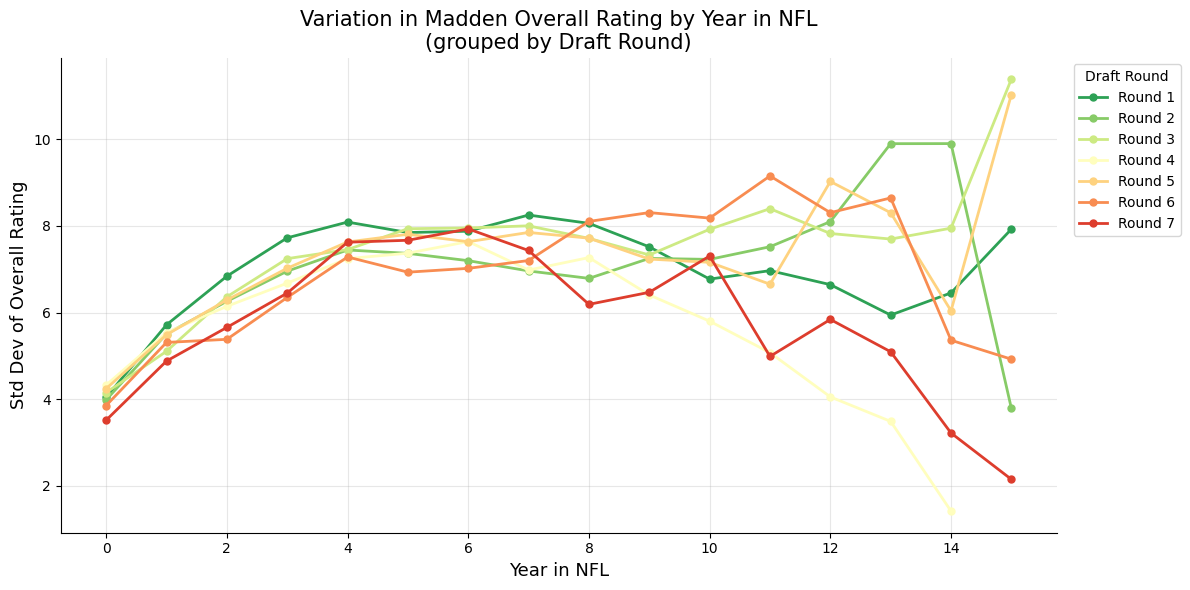

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute std dev of overallrating by draft_round and year_in_nfl
variation = (
    df
    .groupby(["draft_round", "year_in_nfl"])["overallrating"]
    .std()
    .reset_index()
    .rename(columns={"overallrating": "std_overall"})
)

# Filter to reasonable ranges
variation = variation[
    (variation["year_in_nfl"] <= 15) &
    (variation["draft_round"] <= 7)
]

fig, ax = plt.subplots(figsize=(12, 6))

palette = sns.color_palette("RdYlGn_r", n_colors=7)  # round 1 = green, round 7 = red

for round_num, group in variation.groupby("draft_round"):
    ax.plot(
        group["year_in_nfl"],
        group["std_overall"],
        marker="o",
        label=f"Round {int(round_num)}",
        color=palette[int(round_num) - 1],
        linewidth=2,
        markersize=5,
    )

ax.set_xlabel("Year in NFL", fontsize=13)
ax.set_ylabel("Std Dev of Overall Rating", fontsize=13)
ax.set_title("Variation in Madden Overall Rating by Year in NFL\n(grouped by Draft Round)", fontsize=15)
ax.legend(title="Draft Round", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(True, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

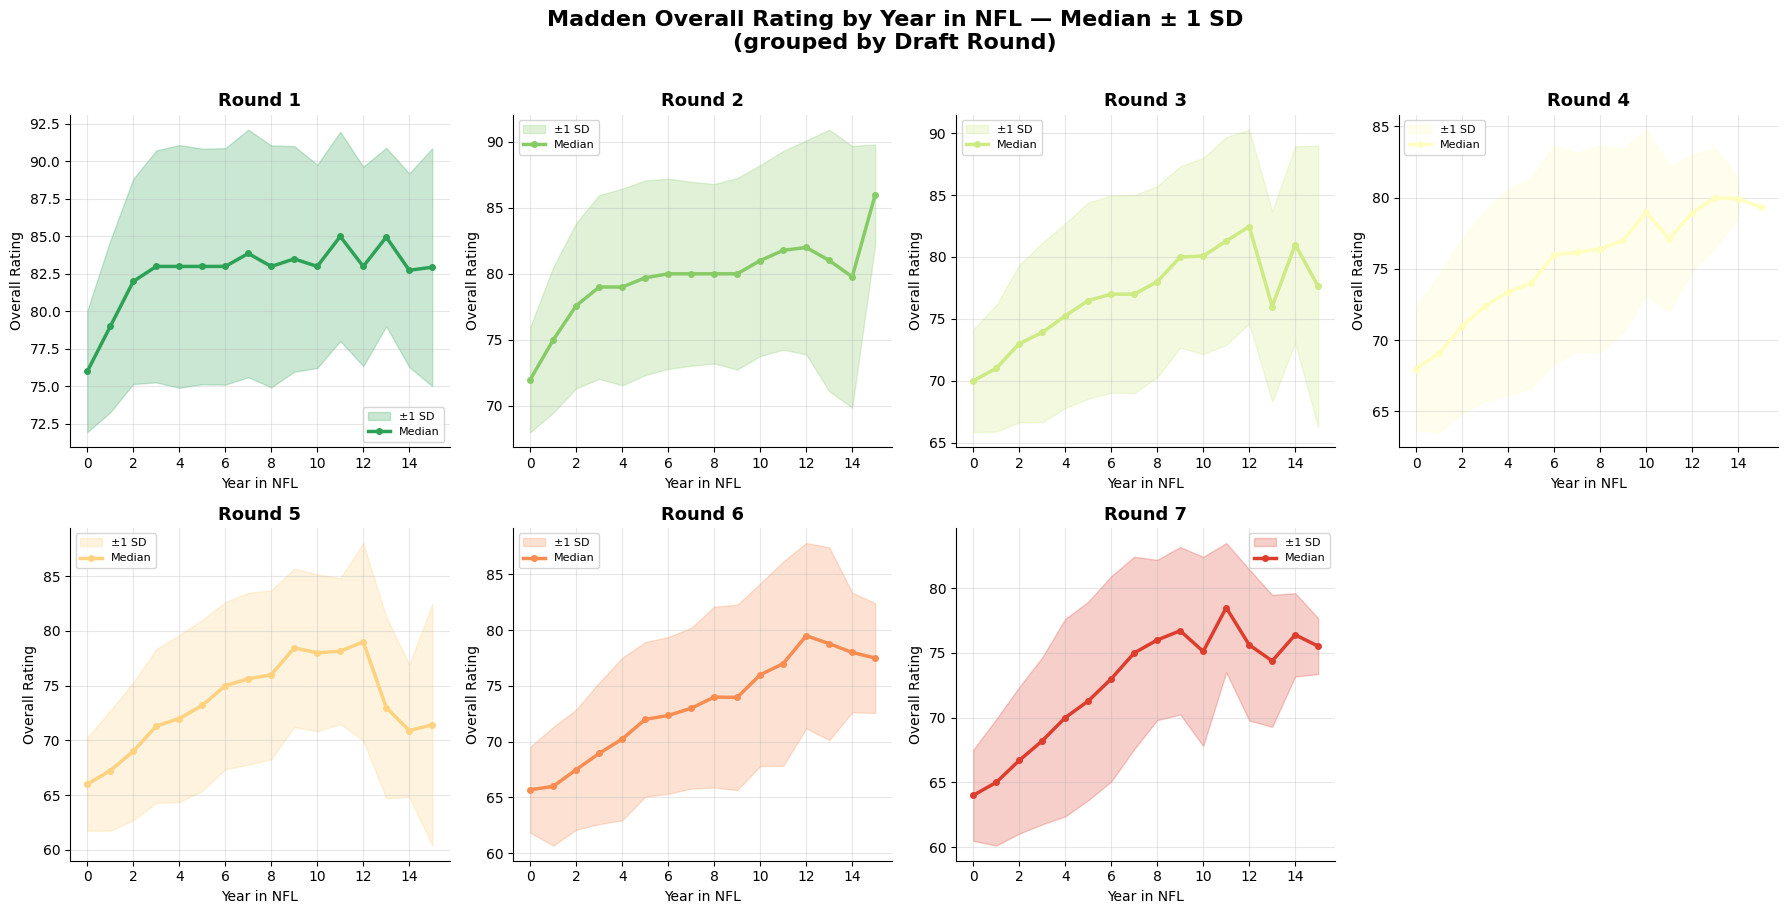

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes = axes.flatten()

palette = sns.color_palette("RdYlGn_r", n_colors=7)

stats = (
    df
    .groupby(["draft_round", "year_in_nfl"])["overallrating"]
    .agg(["median", "std"])
    .reset_index()
    .rename(columns={"median": "median_overall", "std": "std_overall"})
)

stats = stats[
    (stats["year_in_nfl"] <= 15) &
    (stats["draft_round"] <= 7)
]

for i, (round_num, group) in enumerate(stats.groupby("draft_round")):
    ax = axes[i]
    color = palette[int(round_num) - 1]

    group = group.sort_values("year_in_nfl")
    x = group["year_in_nfl"]
    med = group["median_overall"]
    std = group["std_overall"]

    ax.fill_between(x, med - std, med + std, alpha=0.25, color=color, label="±1 SD")
    ax.plot(x, med, color=color, linewidth=2.5, marker="o", markersize=4, label="Median")

    ax.set_title(f"Round {int(round_num)}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Year in NFL", fontsize=10)
    ax.set_ylabel("Overall Rating", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

# Hide the unused 8th subplot
axes[-1].set_visible(False)

fig.suptitle(
    "Madden Overall Rating by Year in NFL — Median ± 1 SD\n(grouped by Draft Round)",
    fontsize=16, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.show()

### Next


In [6]:
df = madden_long.merge(players[["rookie_season", "last_season", "gsis_id", "draft_year", "draft_round", "draft_pick"]], left_on="player_id", right_on="gsis_id")
df

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,rookie_season,last_season,gsis_id,draft_year,draft_round,draft_pick
0,00-0004543,SHANEDRONETT_d_line,DronSh20,Shane Dronett,def,d_line,DL,2001,ATL,1.0,75.000000,53.000000,65.000000,58.000000,79.0000,84.000000,84.000000,79.000000,81.000000,43.000000,7.347195,4,11,35.306958,66.518996,11.000000,20.000000,20.0000,20.00000,16.696763,19.318944,28.000000,-2.261149,-1.546120,2.340851,3.478826,22.000000,6.519022,10.549796,11.996476,9.005981,8.412261,8.034401,16.000000,16.000000,0.483380,15.249485,17.082539,81.000000,51.752871,8.673651,66.456748,21.000000,24.000000,0.675884,2001,1992,2002,00-0004543,1992.0,2.0,54.0
1,00-0012842,JASONPETER_d_line,PeteJa20,Jason Peter,def,d_line,DL,2001,CAR,1.0,74.000000,66.000000,74.000000,64.000000,84.0000,78.000000,84.000000,80.000000,67.000000,51.000000,7.889415,5,7,47.836493,58.864012,10.000000,21.000000,21.0000,21.00000,18.295792,21.480056,24.000000,0.980120,-0.375920,8.238861,7.495244,21.000000,5.982346,9.869347,12.073328,5.724684,4.637821,9.797546,27.000000,18.000000,9.782409,19.028072,23.221269,72.000000,54.472249,12.652961,69.286862,18.000000,19.000000,3.772098,2001,1998,2001,00-0012842,1998.0,1.0,14.0
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.000000,72.000000,62.000000,75.000000,65.0000,70.000000,70.000000,82.000000,64.000000,52.000000,25.090824,8,9,51.656422,55.302556,32.000000,14.000000,14.0000,14.00000,11.934877,13.800475,24.000000,19.994085,18.021897,24.959818,21.045019,40.000000,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.000000,24.000000,-5.096101,32.979157,37.209780,74.000000,51.286358,28.416331,72.007990,11.000000,33.000000,1.131921,2001,1998,2009,00-0009978,1998.0,3.0,65.0
3,00-0002142,JUNIORBRYANT_d_line,BryaJu20,Junior Bryant,def,d_line,DL,2001,SF,1.0,72.000000,49.000000,62.000000,55.000000,81.0000,81.000000,84.000000,84.000000,79.000000,43.000000,5.111116,5,9,36.576845,65.727568,24.000000,11.000000,11.0000,11.00000,9.494538,11.093699,14.000000,-8.819708,-2.912042,-5.407254,-5.493794,14.000000,7.008726,10.117281,12.240143,-1.108932,-1.319240,1.354661,29.000000,27.000000,7.181824,14.503342,17.728221,82.000000,51.302609,6.509206,64.948565,12.000000,14.000000,1.162361,2001,1995,2002,00-0002142,NaN,NaN,NaN
4,00-0018054,REINARDWILSON_d_line,WilsRe20,Reinard Wilson,def,d_line,DL,2001,CIN,1.0,69.000000,70.000000,70.000000,65.000000,78.0000,69.000000,78.000000,77.000000,65.000000,50.000000,16.121217,7,9,50.852213,56.274011,31.000000,16.000000,16.0000,16.00000,16.041897,17.385281,26.000000,12.748664,9.218156,18.243457,14.183115,26.000000,7.190139,10.575620,11.980324,12.149089,9.289694,10.978948,13.000000,9.000000,-2.869764,26.808503,31.008670,69.000000,51.400124,22.833778,69.883798,17.000000,21.000000,2.545349,2001,1997,2003,00-0018054,1997.0,1.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58224,00-0039172,JAKEBATES_19990303,BateJa00,Jake Bates,st,special_teams,K,2025,DET,4.0,76.000000,61.000000,74.000000,72.000000,82.0000,35.000000,61.000000,89.000000,59.000000,60.000000,10.000000,3,4,51.000000,15.000000,32.000000,28.000000,22.0000,13.00000,20.000000,20.000000,32.000000,20.000000,10.000000,10.000000

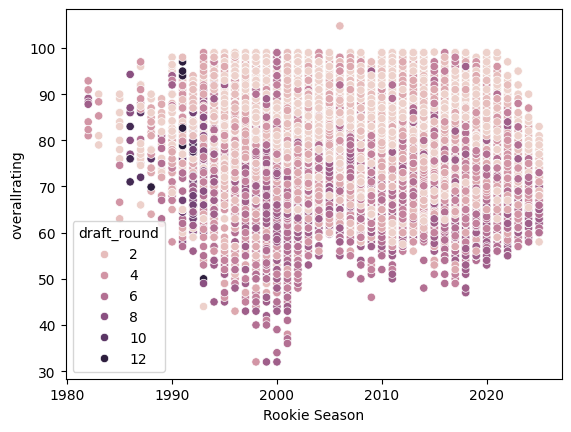

In [12]:
sns.scatterplot(data = df,
                x="rookie_season",
                y = "overallrating",
                hue="draft_round")
plt.xlabel("Rookie Season")
plt.ylabel = ("Overall Rating")
plt.show()

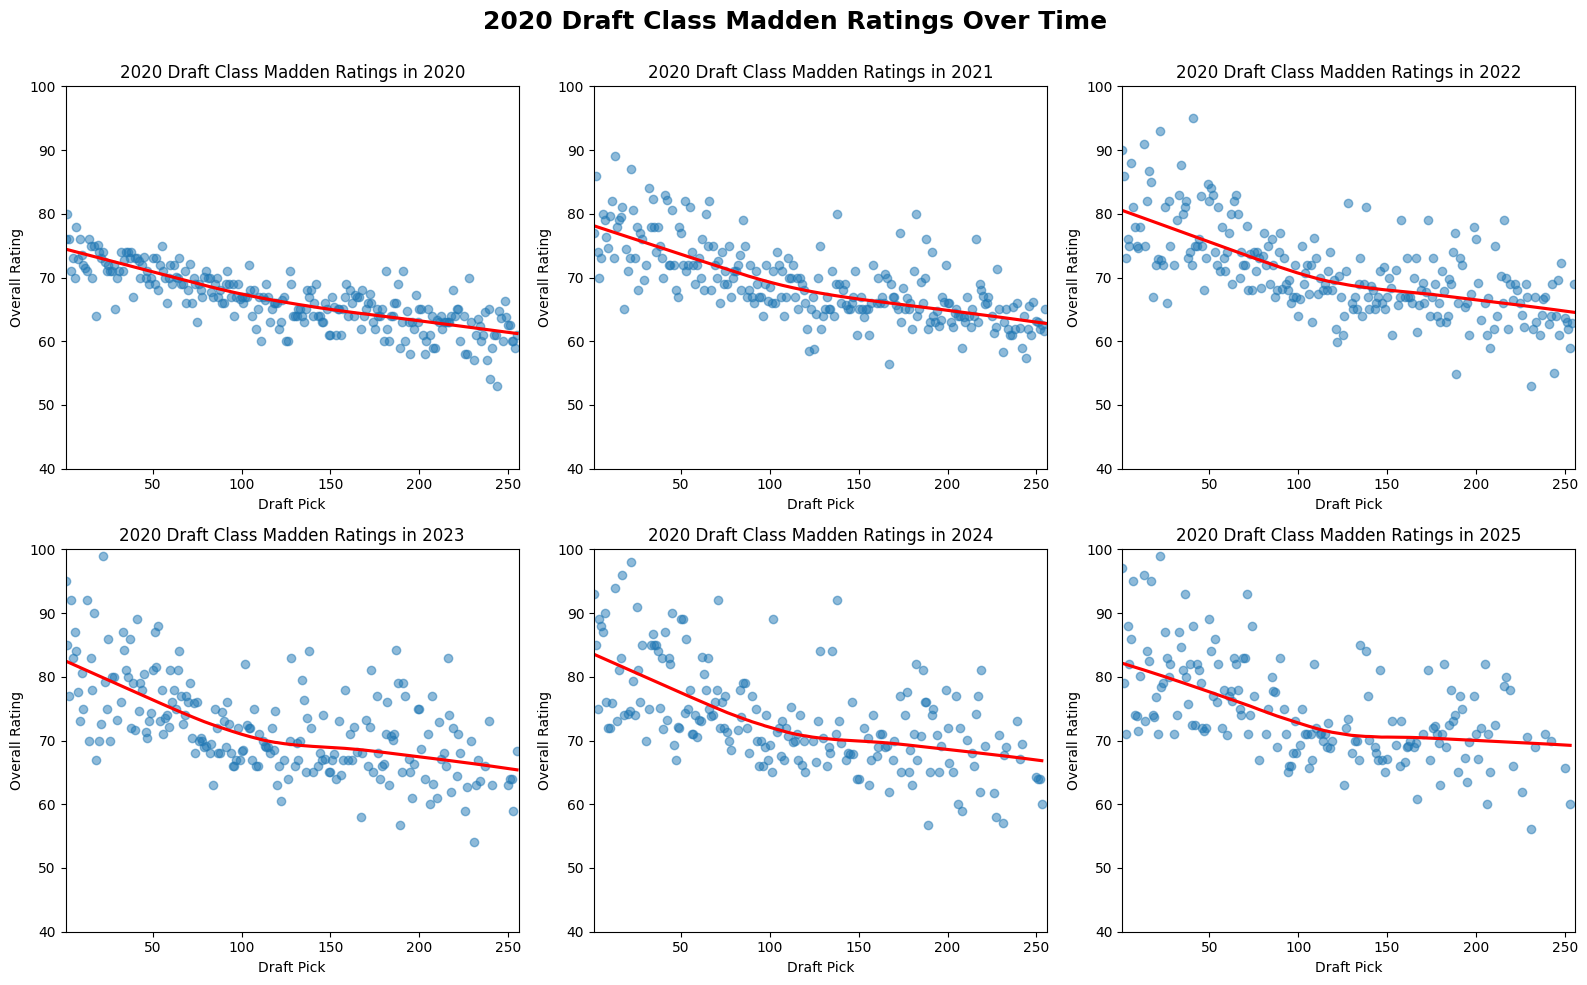

In [37]:
years = [2020, 2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    ax.set_xlim(1, 256)
    ax.set_ylim(40, 100)
    sns.regplot(data=df.query("draft_year == 2020 and year == @year"),
                    x="draft_pick",
                    y="overallrating",
                    lowess=True,
                    line_kws={"color": "red"},
                    scatter_kws={"alpha": 0.5},
                    ax=ax)
    ax.set_xlabel("Draft Pick")
    ax.set_ylabel("Overall Rating")
    ax.set_title(f"2020 Draft Class Madden Ratings in {year}")

fig.suptitle("2020 Draft Class Madden Ratings Over Time", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [74]:
def plotPos(pos):
    years = [2020, 2021, 2022, 2023, 2024, 2025]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
    axes = axes.flatten()

    for i, year in enumerate(years):
        ax = axes[i]
        ax.set_xlim(1, 256)
        ax.set_ylim(40, 100)
        sns.regplot(data=df.query("draft_year == 2020 and year == @year and position_group == @pos"),
                        x="draft_pick",
                        y="overallrating",
                        lowess=True,
                        line_kws={"color": "red"},
                        scatter_kws={"alpha": 0.5},
                        ax=ax)
        ax.set_xlabel("Draft Pick")
        ax.set_ylabel("Overall Rating")
        ax.set_title(f"2020 Draft Class Madden Ratings in {year}")

    fig.suptitle(f"2020 Draft Class Madden Ratings Over Time for {pos}", fontsize=18, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def plotPos2(pos):
    years = list(range(6))
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
    axes = axes.flatten()

    for i, year in enumerate(years):
        ax = axes[i]
        ax.set_xlim(1, 256)
        ax.set_ylim(40, 100)
        sns.regplot(data=df1.query("year_in_nfl == @year"),
                        x="draft_pick",
                        y="overallrating",
                        lowess=True,
                        line_kws={"color": "red"},
                        scatter_kws={"alpha": 0.5},
                        ax=ax)
        ax.set_xlabel("Draft Pick")
        ax.set_ylabel("Overall Rating")
        ax.set_title(f"Madden Ratings in year {year}")

    fig.suptitle(f"Madden Ratings Over Time for {pos}", fontsize=18, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

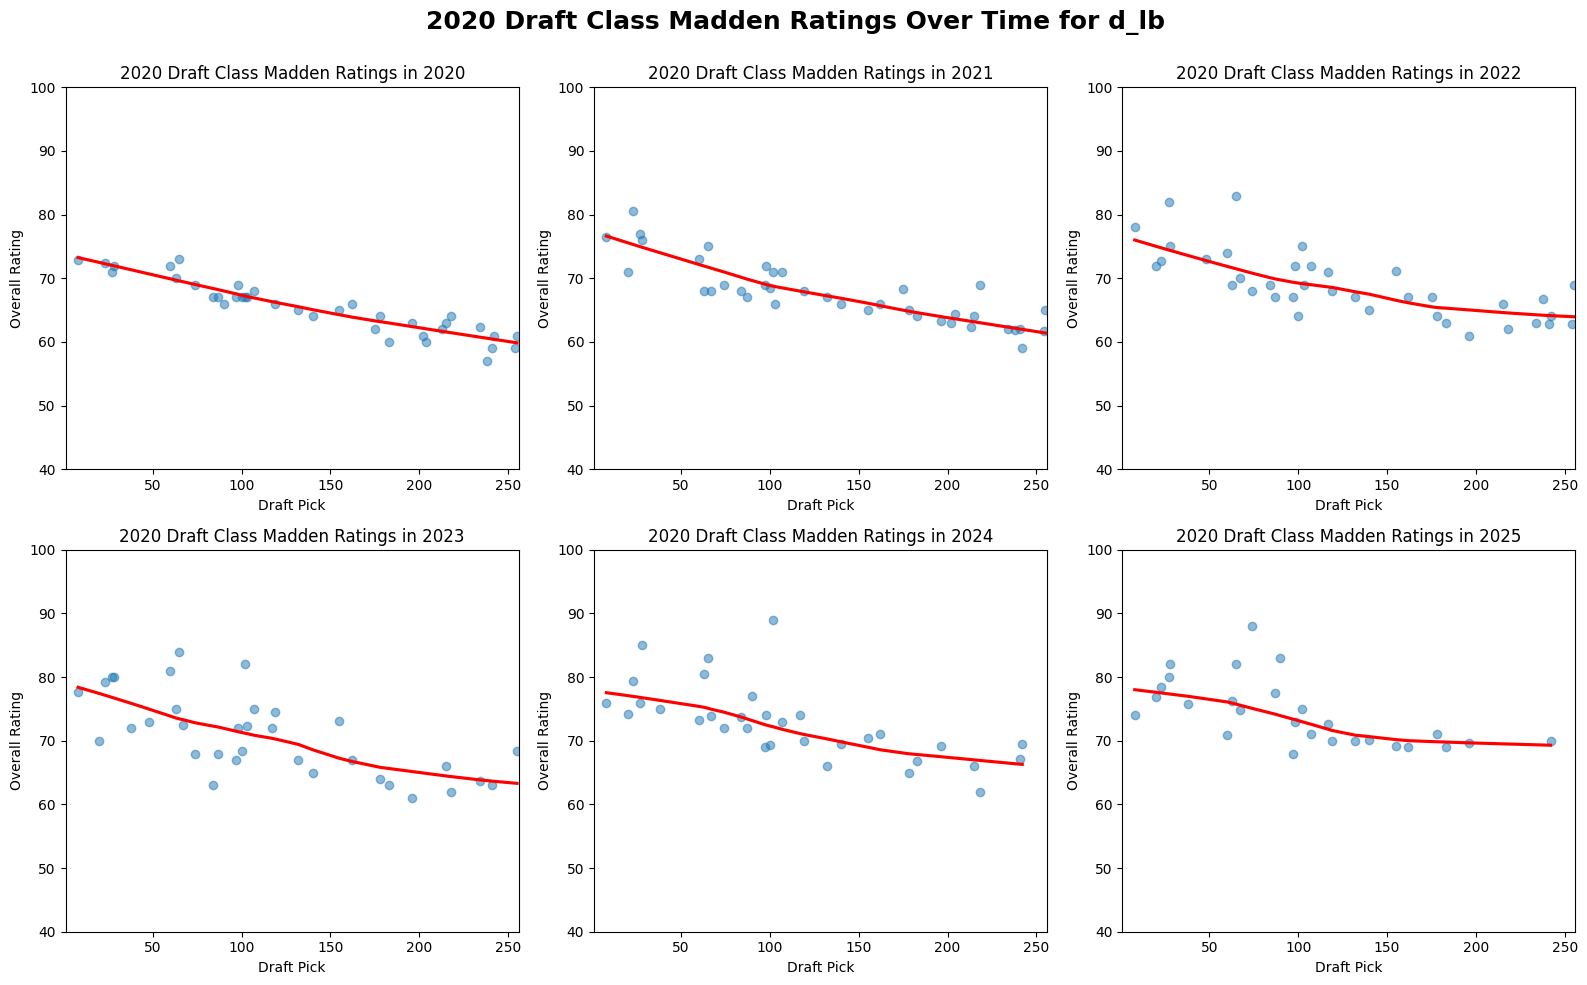

In [49]:
pos1 = df["position_group"].unique()[1]
positions = ['d_line', 'd_lb', 'd_field', 'o_line', 'o_pass', 'o_rush', 'o_te',
       'quarterback', 'special_teams']
plotPos(pos1)

In [63]:
df1 = df.copy()
df1["year_in_nfl"] = df1["year"] - df1["rookie_season"] #rookie year is year 0
df1 = df1.dropna(subset = "draft_pick")
df1 = df1.query("year_in_nfl < 6 and rookie_season > 2000")

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,rookie_season,last_season,gsis_id,draft_year,draft_round,draft_pick,year_in_nfl
116,00-0020459,JAMALREYNOLDS_d_line,ReynJa20,Jamal Reynolds,def,d_line,DL,2001,GB,4.61086,79.0,72.0,83.0,76.0,78.0,73.0,88.0,85.0,64.0,60.0,13.928256,5,11,47.738742,52.942789,15.0,21.0,21.0,21.0,17.356663,20.805043,15.0,14.519759,8.996859,23.991852,22.437692,33.0,10.151774,11.892505,12.693256,12.293937,7.395690,14.332235,11.0,12.0,3.324223,27.272776,29.680041,69.0,53.186884,22.930081,74.745695,19.0,22.0,1.439833,2001,2001,2003,00-0020459,2001.0,1.0,10.0,0
117,00-0020535,JUSTINSMITH_19790920,SmitJu20,Justin Smith,def,d_line,DL,2001,CIN,4.61086,79.0,67.0,82.0,76.0,85.0,77.0,80.0,73.0,66.0,58.0,7.920525,3,6,40.323669,59.834627,22.0,21.0,21.0,21.0,16.433431,20.294446,15.0,8.629725,2.961450,18.548155,11.311415,19.0,11.235782,11.530147,11.692559,6.724469,2.138416,16.285808,23.0,22.0,20.447276,25.551392,30.165120,72.0,50.433495,13.792209,76.216600,20.0,11.0,3.217043,2001,2001,2014,00-0020535,2001.0,1.0,4.0,0
120,00-0020426,CASEYHAMPTON_19770903,HampCa00,Casey Hampton,def,d_line,DL,2001,PIT,4.61086,77.0,63.0,66.0,59.0,89.0,90.0,82.0,87.0,69.0,48.0,9.579246,3,6,35.761971,64.084072,24.0,14.0,14.0,14.0,12.866408,15.389567,31.0,-5.764664,-5.385784,-1.178711,-7.282151,16.0,6.692096,11.166714,13.290851,7.366448,2.750697,15.042041,18.0,18.0,-1.104908,16.861550,22.657078,82.0,54.847755,7.175994,70.210879,11.0,12.0,4.719639,2001,2001,2012,00-0020426,2001.0,1.0,19.0,0
121,00-0020524,GERARDWARREN_d_line,WarrGe20,Gerard Warren,def,d_line,DL,2001,CLE,4.61086,76.0,68.0,77.0,66.0,85.0,86.0,85.0,90.0,64.0,58.0,9.322765,3,7,35.344868,58.098234,15.0,20.0,20.0,20.0,16.730251,20.169793,14.0,6.159716,2.064359,9.003112,5.489941,30.0,11.909426,11.950203,11.538211,7.432284,5.451204,15.074740,15.0,20.0,15.245089,20.165591,25.608706,79.0,54.883390,6.512757,73.534821,18.0,10.0,3.707843,2001,2001,2011,00-0020524,2001.0,1.0,3.0,0
123,00-0020489,ANDRECARTER_d_line,CartAn20,Andre Carter,def,d_line,DL,2001,SF,4.61086,75.0,70.0,72.0,74.0,79.0,73.0,80.0,79.0,66.0,55.0,3.157469,4,5,43.595785,57.786312,11.0,19.0,19.0,19.0,19.153590,22.933768,14.0,7.543041,-1.469502,25.255121,20.726918,19.0,11.903602,12.196510,11.639022,9.595415,4.653976,19.316321,10.0,32.0,6.313320,33.531732,34.206993,70.0,48.385150,19.021440,70.197263,10.0,25.0,3.612164,2001,2001,2013,00-0020489,2001.0,1.0,7.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58199,00-0037284,None,AraiMa00,Matt Araiza,st,special_teams,P,2025,KC,3.00000,75.0,67.0,87.0,83.0,87.0,49.0,76.0,89.0,55.0,78.0,12.000000,3,2,57.000000,19.000000,35.0,30.0,25.0,20.0,19.000000,24.000000,35.0,25.000000,10.000000,23.000000,32.000000,27.0,15.000000,14.988416,15.000000,20.000000,15.000000,15.000000,16.0,17.0,17.000000,11.000000,15.000000,34.0,24.000000,10.000000,38.000000,79.0,98.0,10.000000,2025,2024,2026,00-0037284,2022.0,6.0,180.0,1
58200,00-0038567,CHADRYLAND_19991015,RylaCh00,Chad Ryland,st,special_teams,K,2025,ARI,3.00000,74.0,60.0,74.0,73.0,84.0,40.0,63.0,92.0,61.0,66.0,10.000000,3,4,55.000000,10.000000,34.0,35.0,30.0,25.0,20.000000,22.000000,32.0,10.000000,10.000000,10.000000,10.000000,35.0,10.000000,9.987087,10.000000,12.00

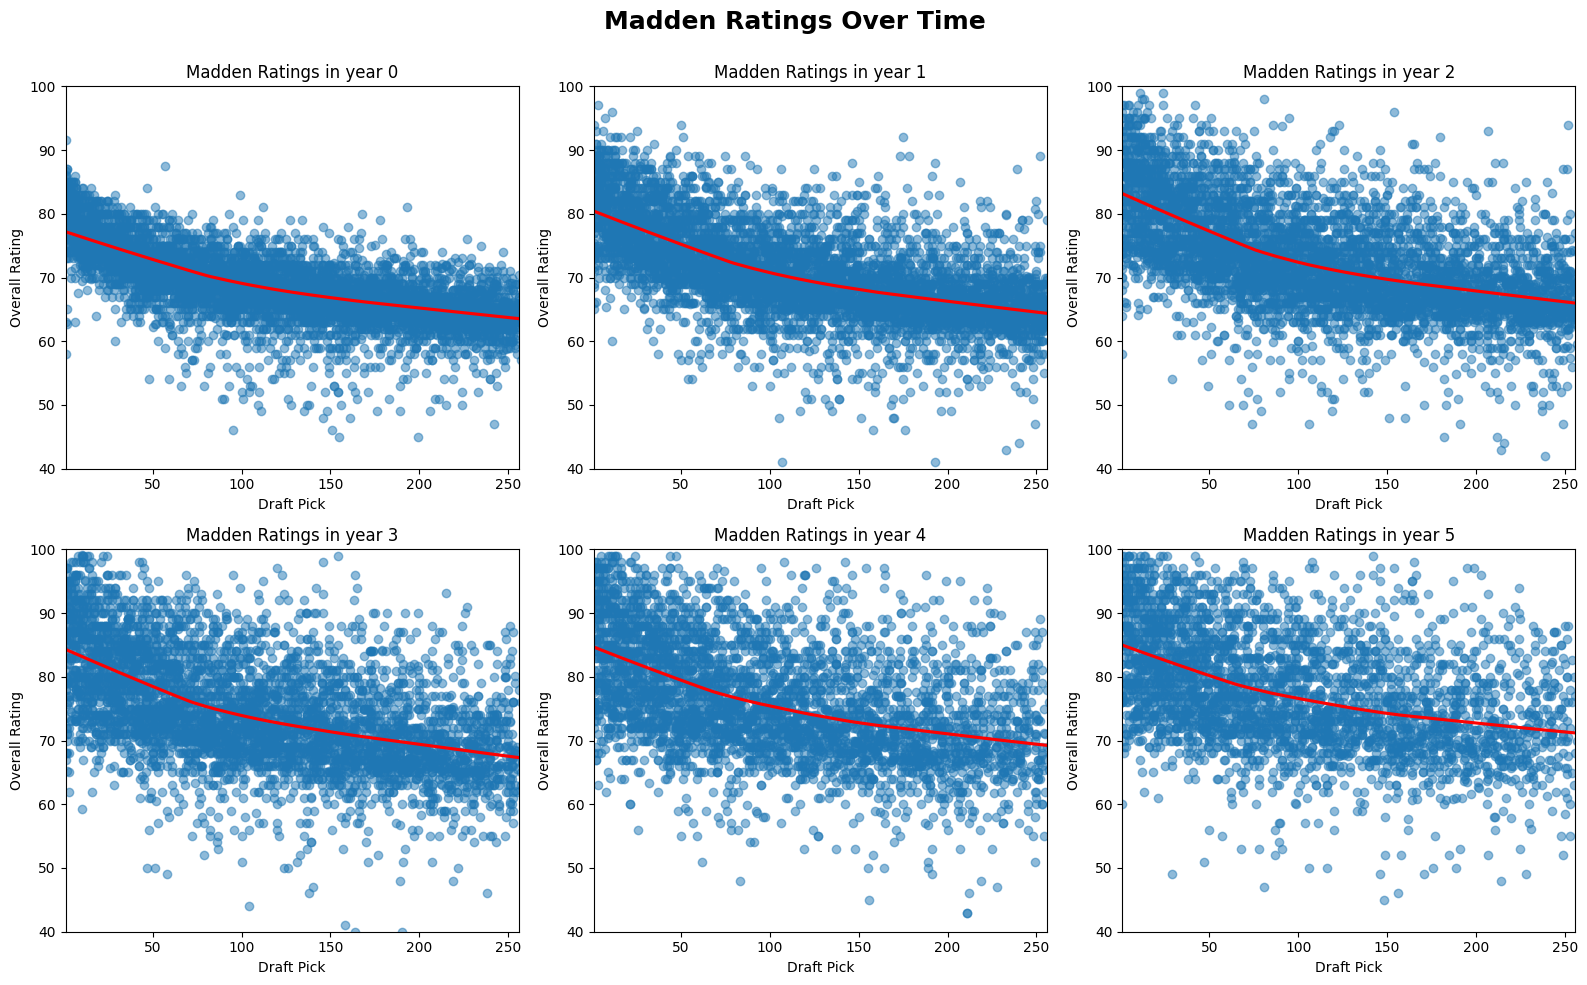

In [71]:
years = list(range(6))
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    ax.set_xlim(1, 256)
    ax.set_ylim(40, 100)
    sns.regplot(data=df1.query("year_in_nfl == @year"),
                    x="draft_pick",
                    y="overallrating",
                    lowess=True,
                    line_kws={"color": "red"},
                    scatter_kws={"alpha": 0.5},
                    ax=ax)
    ax.set_xlabel("Draft Pick")
    ax.set_ylabel("Overall Rating")
    ax.set_title(f"Madden Ratings in year {year}")

fig.suptitle(f"Madden Ratings Over Time", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

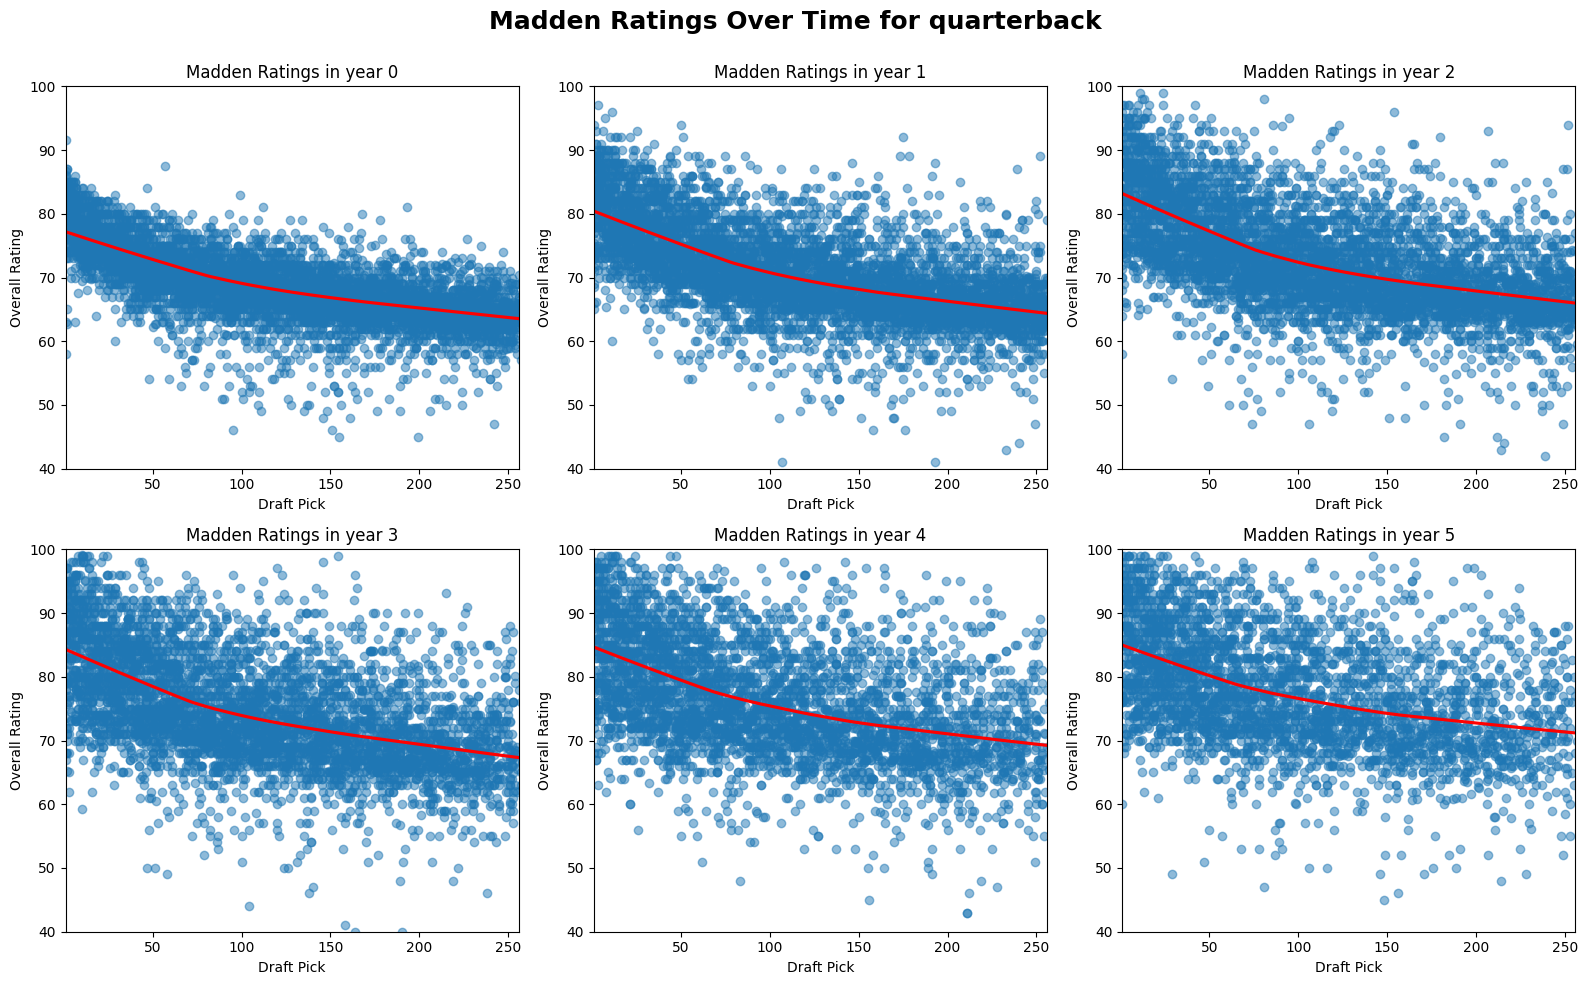

In [75]:
plotPos2("quarterback")

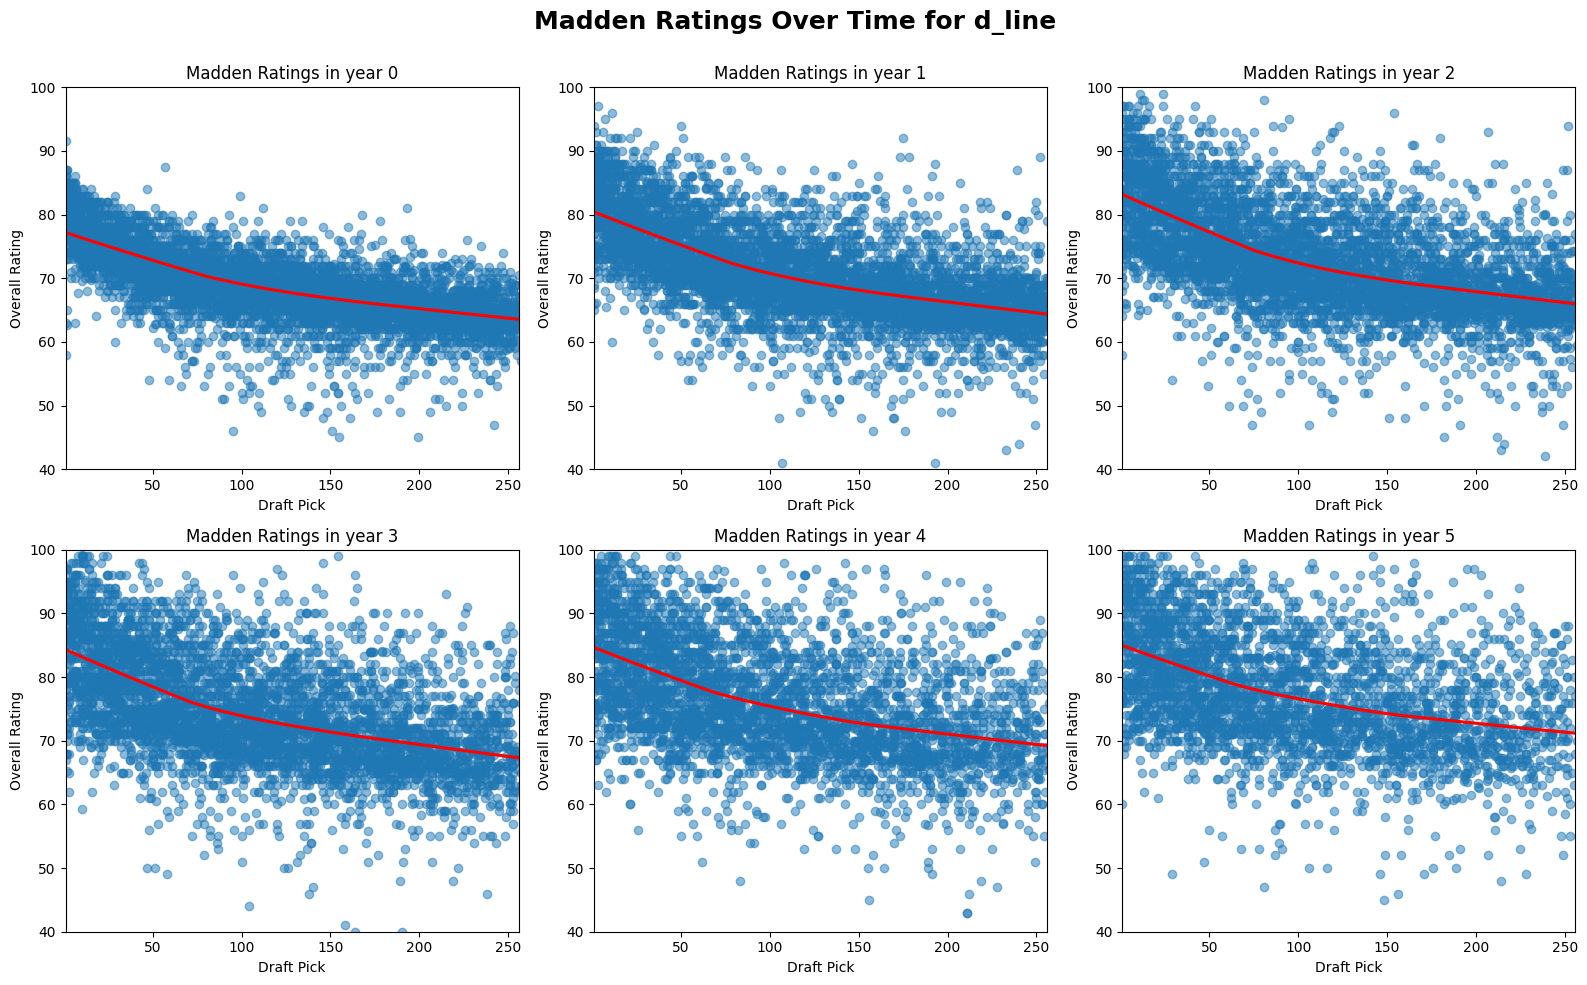

In [77]:
plotPos2("d_line")